# Relaciones entre variables

In [4]:
from proyecto_ciencia_de_datos.config import PROCESSED_DATA_DIR
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

axa_df = pd.read_csv(PROCESSED_DATA_DIR / 'axa_EDA_son.csv', sep=',', header='infer', low_memory=False)
inegi_df = pd.read_csv(PROCESSED_DATA_DIR / 'inegi_EDA_son.csv', sep=',', header='infer')
weather_df = pd.read_csv(PROCESSED_DATA_DIR / 'weather_EDA_son.csv', sep=',', header='infer')

## AXA

Una matriz de correlacion para visualizar los valores numericos del dataset

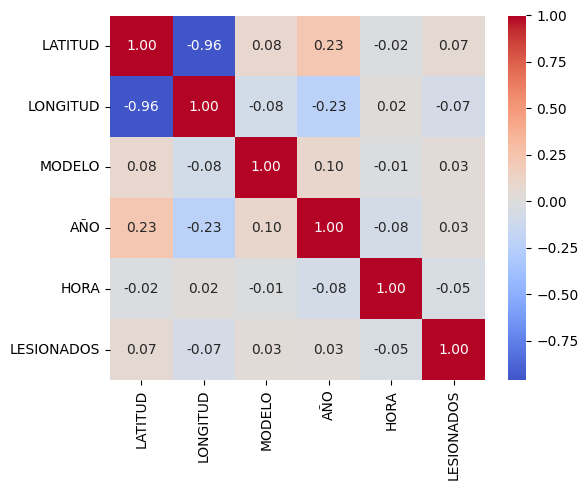

In [5]:
# Create correlation matrix for numerical columns
corr = axa_df[['LATITUD','LONGITUD','MODELO','AÑO','HORA','LESIONADOS']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.tight_layout()
plt.show()

### Visualizacion para las variables categoricas
#### Usando Heatmaps

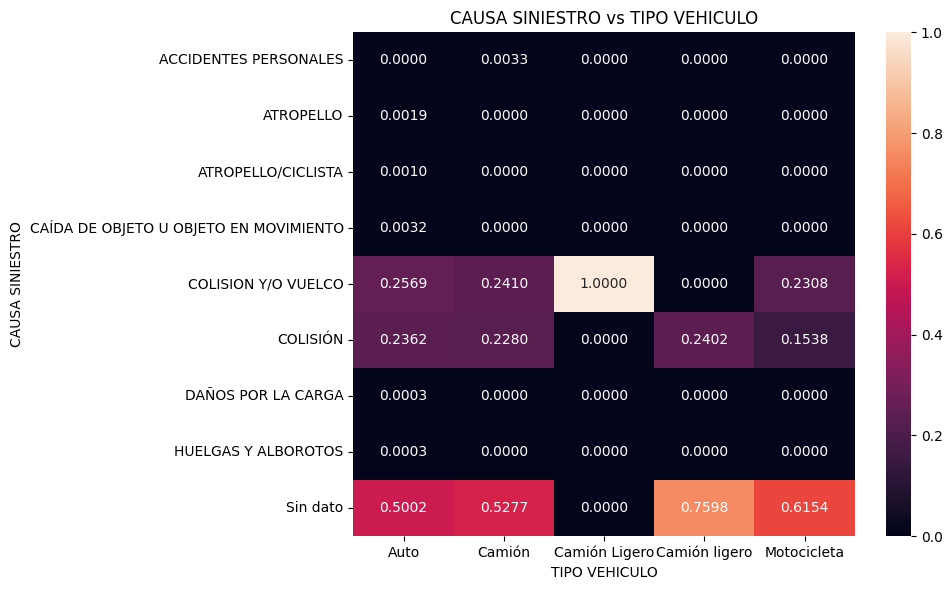

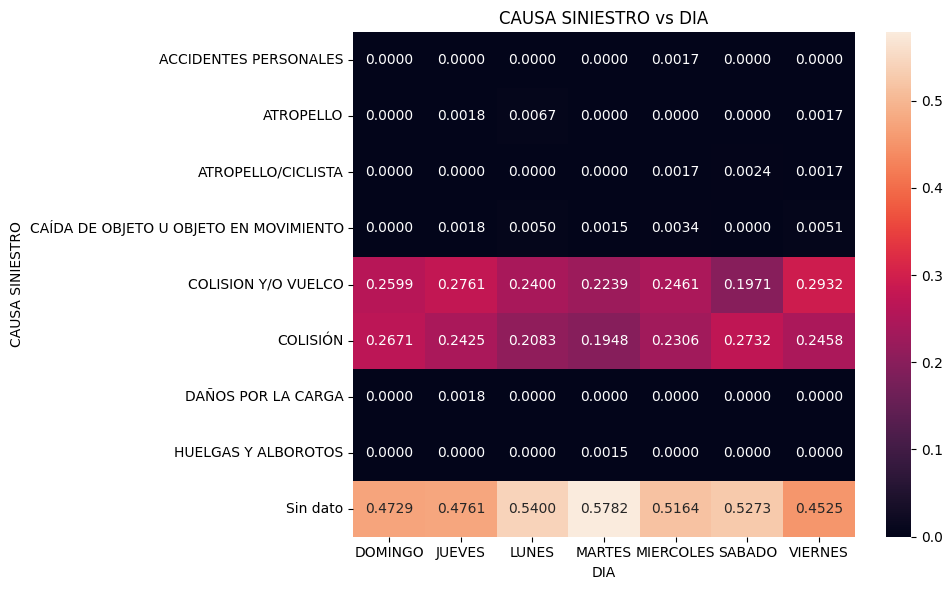

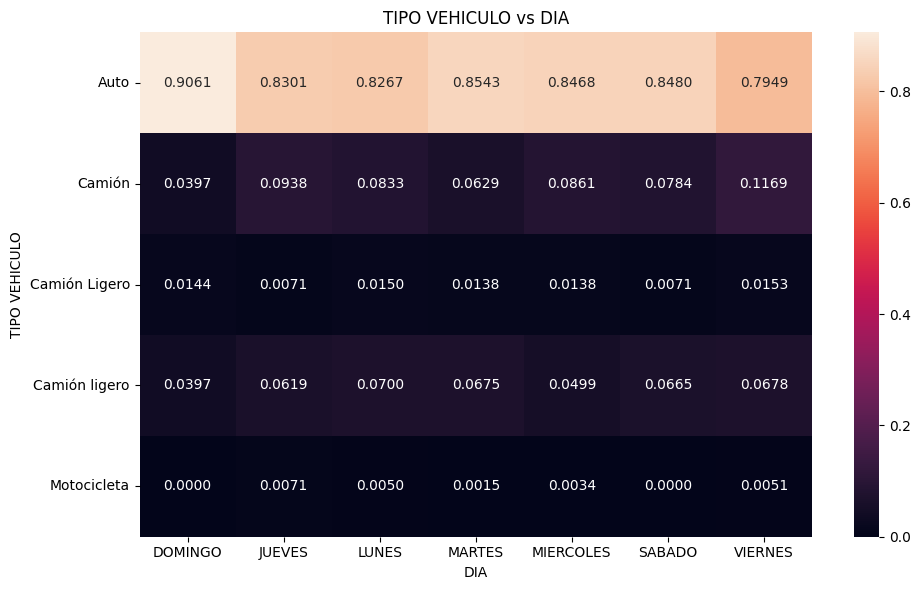

In [6]:
# Lista de columnas categóricas
cat_cols = ['CAUSA SINIESTRO', 'TIPO VEHICULO', 'DIA']
# Ciudad excluida por que no se ve bien en este tipo de grafico

# Generar combinaciones de dos columnas categóricas
pairs = []
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        pairs.append((cat_cols[i], cat_cols[j]))

# Heatmaps
for col1, col2 in pairs:
    plt.figure(figsize=(10, 6))

    # Tabla de contingencia con categorías completas
    ct = pd.crosstab(
        axa_df[col1],
        axa_df[col2],
        dropna=False,
        normalize='columns'   # Normaliza por fila
    )

    sns.heatmap(ct, annot=True, fmt=".4f")
    plt.title(f"{col1} vs {col2}")
    plt.tight_layout()
    plt.show()


OBSERVACIONES:

Podemos observar que:
- Los accidentes más comunes en los datos de AXA son causados por **autos** personales (Por que tienen la mayor cantidad de conductores)
- El día con más accidentes es el **Martes**
- Los accidentes más comunes son **Colisión** y **Colisión Y/O Vuelco** (Excluyendo 'Sin Dato')

La mayoria de correlaciones son hacia los Autos, que pasa si vemos la correlacion sin ellos?

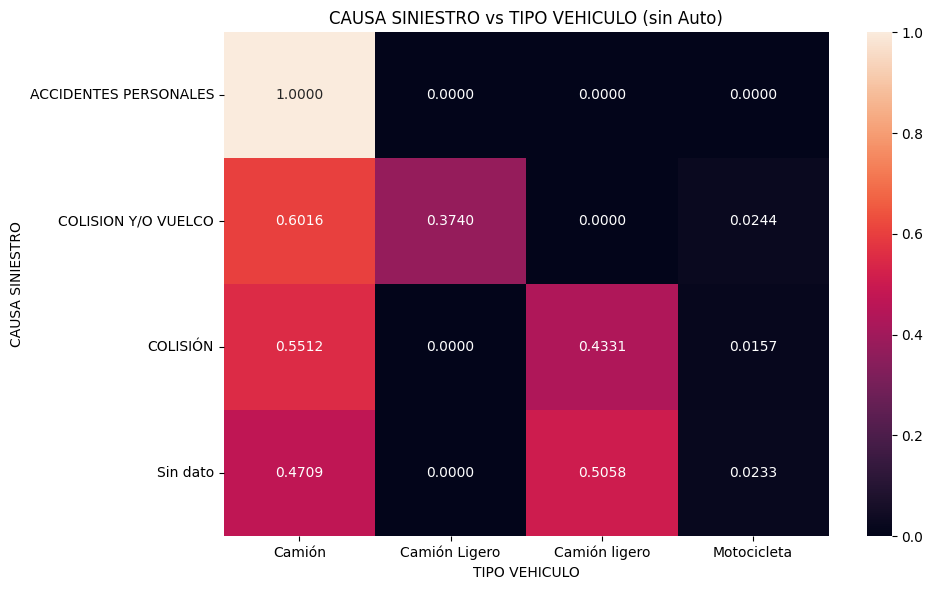

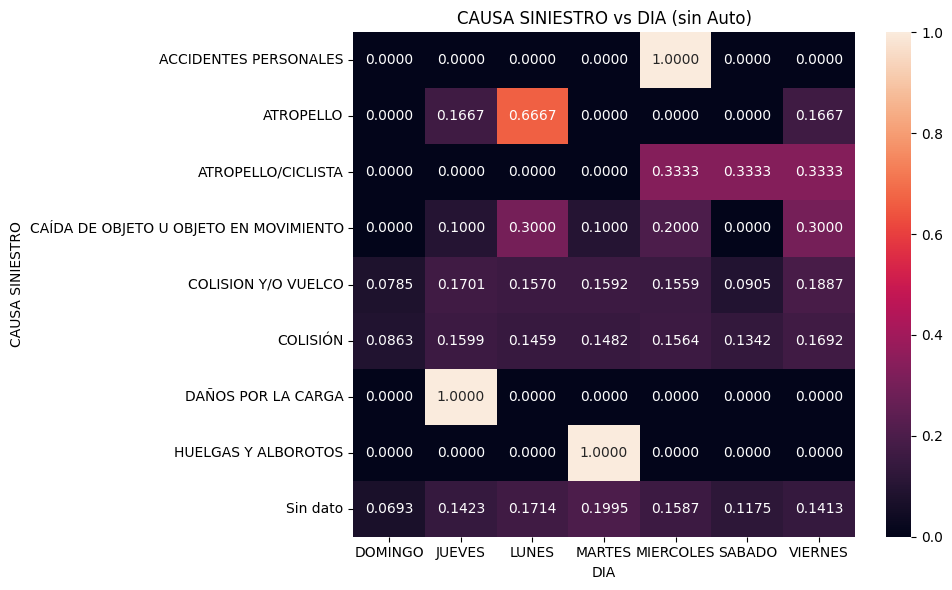

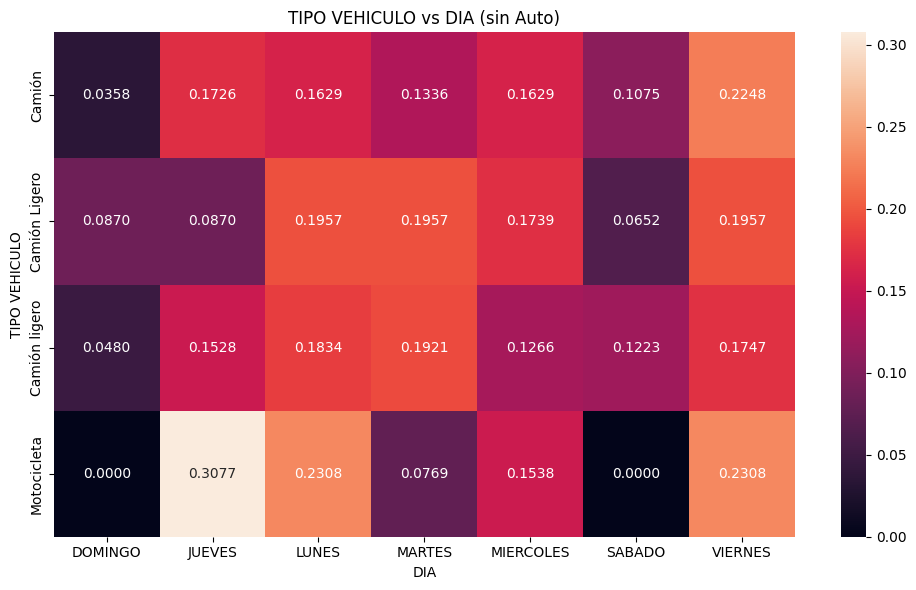

In [7]:
cat_cols = ['CAUSA SINIESTRO', 'TIPO VEHICULO', 'DIA']

# Generar pares
pairs = []
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        pairs.append((cat_cols[i], cat_cols[j]))

for col1, col2 in pairs:
    # Copia filtrada solo para la gráfica actual
    df_plot = axa_df.copy()

    # Excluir "Auto" cuando TIPO VEHICULO aparece en cualquiera de las dos columnas
    if col1 == 'TIPO VEHICULO' or col2 == 'TIPO VEHICULO':
        df_plot = df_plot[df_plot['TIPO VEHICULO'] != 'Auto']

    # Tabla normalizada por fila
    ct = pd.crosstab(
        df_plot[col1],
        df_plot[col2],
        dropna=False,
        normalize='index'
    )

    # Eliminar filas/columnas de Auto si quedaron en el índice accidentalmente
    if 'Auto' in ct.index:
        ct = ct.drop(index='Auto')
    if 'Auto' in ct.columns:
        ct = ct.drop(columns='Auto')
        

    # Graficar
    plt.figure(figsize=(10, 6))
    sns.heatmap(ct, annot=True, fmt=".4f")
    plt.title(f"{col1} vs {col2} (sin Auto)")
    plt.tight_layout()
    plt.show()


OBSERVACIONES
Al haber eliminado los autos personales de la grafica, podemos notar nuevas relaciones:

- Los accidentes más comunes en los datos de AXA son causados por *Camiones*
- Ahora ya no hay un día con más accidentes, ya que ahora se distribuye los dias con accidentes en una forma más general 
- Los accidentes más comunes ya no son **Colisión** y **Colisión Y/O Vuelco** pero ahora la cantidad de **'Sin Dato'** se reducío considerablemente, lo cual significa que la mayoria de estos son por **autos** personales
- Los accidentes **Personales** parecen ser causados solamente por **Camión** y solo el **Miercoles**, esto puede ser por que no muchos accidentes son marcados como **Personales** o son registrados como **'Sin Dato'**

## INEGI

Primero una grafica de correlación para observar si hay alguna relación obvia entre las variables categoricas:

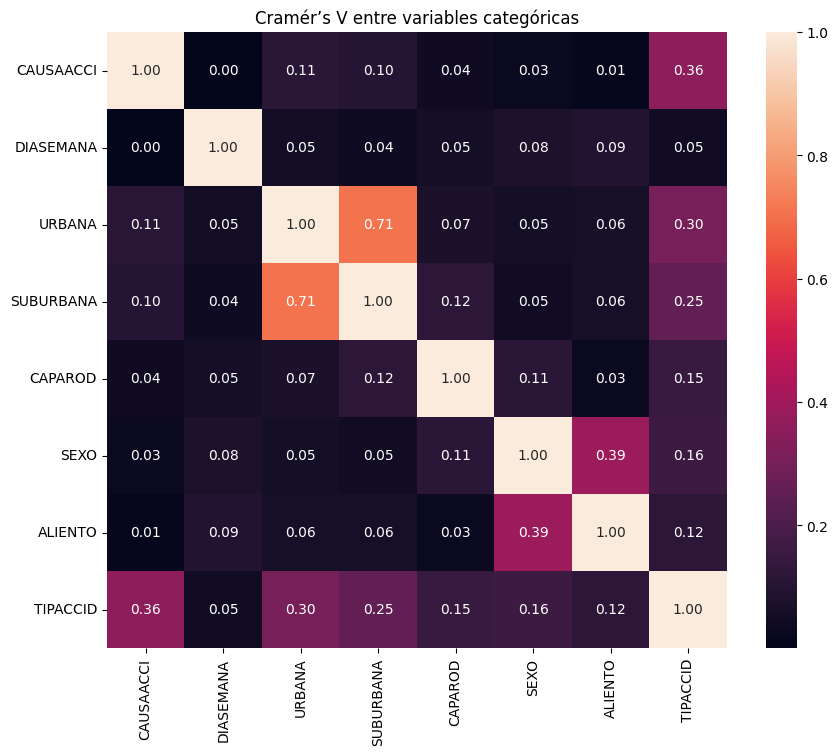

In [8]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    phi2 = chi2 / n
    r, k = ct.shape
    phi2_corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    r_corr = r - ((r-1)**2)/(n-1)
    k_corr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2_corr / min((k_corr-1),(r_corr-1)))

cats = ['CAUSAACCI','DIASEMANA','URBANA','SUBURBANA','CAPAROD','SEXO','ALIENTO', 'TIPACCID']

mat = pd.DataFrame(index=cats, columns=cats, dtype=float)

for c1 in cats:
    for c2 in cats:
        mat.loc[c1,c2] = cramers_v(inegi_df[c1], inegi_df[c2])

plt.figure(figsize=(10,8))
sns.heatmap(mat, annot=True, fmt=".2f")
plt.title("Cramér’s V entre variables categóricas")
plt.show()


Parece haber algunas relaciones entre la categoria **Suburbana** con **Urbana** y **Sexo** con **Aliento**, además de que el tipo de accidente tiene mucha relación con todas las variables, habra que ver las relaciones de las categorias más a fondo.

### Observando relaciones con tipo de accidente
#### Utilizando Heatmaps

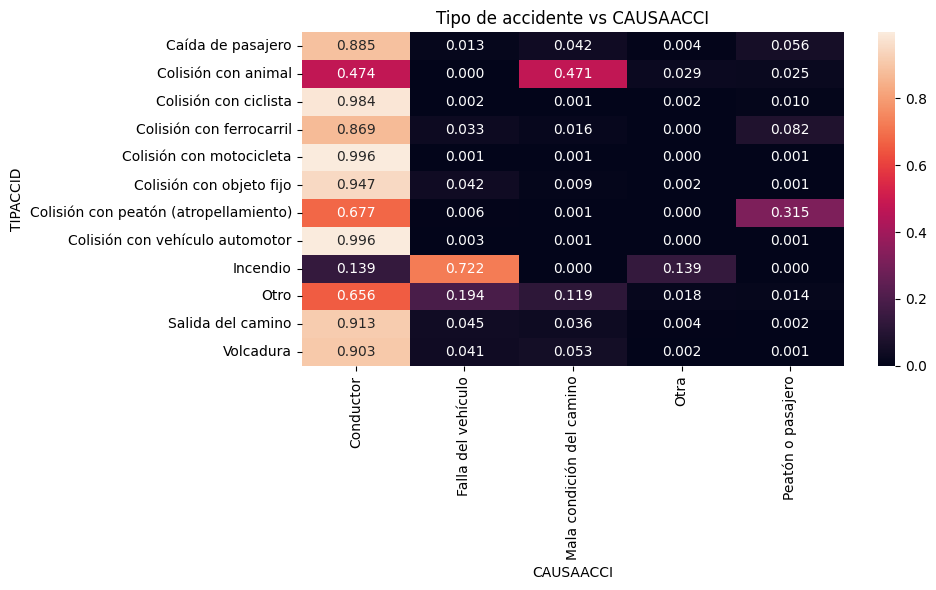

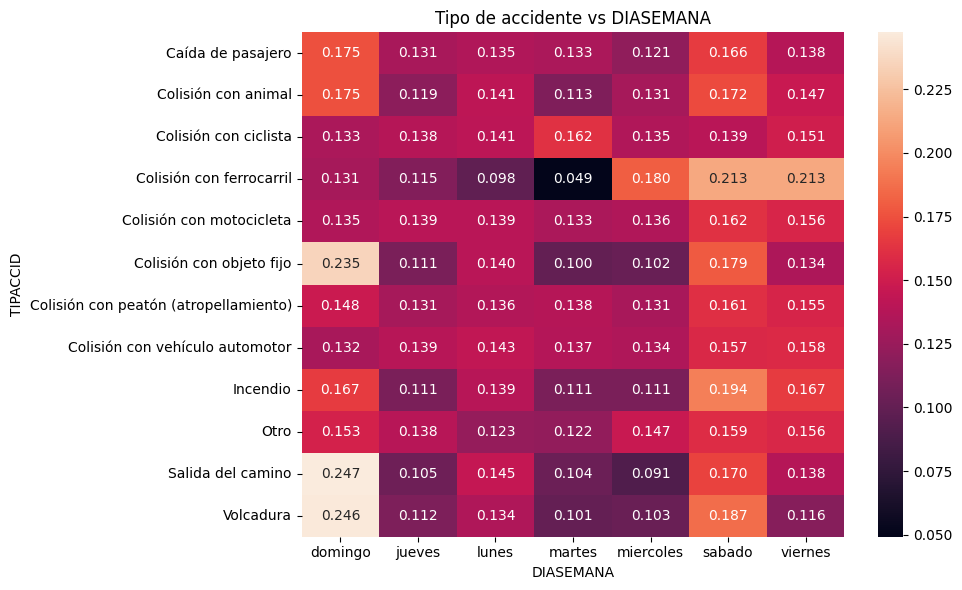

In [9]:
# Columnas categóricas importantes
cat_cols = [
    'CAUSAACCI',
    'DIASEMANA'
]

# Heatmaps
for col in cat_cols:

    ct = pd.crosstab(
        inegi_df['TIPACCID'],
        inegi_df[col],
        dropna=True,
        normalize='index'
    )

    plt.figure(figsize=(10, 6))
    sns.heatmap(ct, annot=True, fmt=".3f")
    plt.title(f"Tipo de accidente vs {col}")
    plt.tight_layout()
    plt.show()


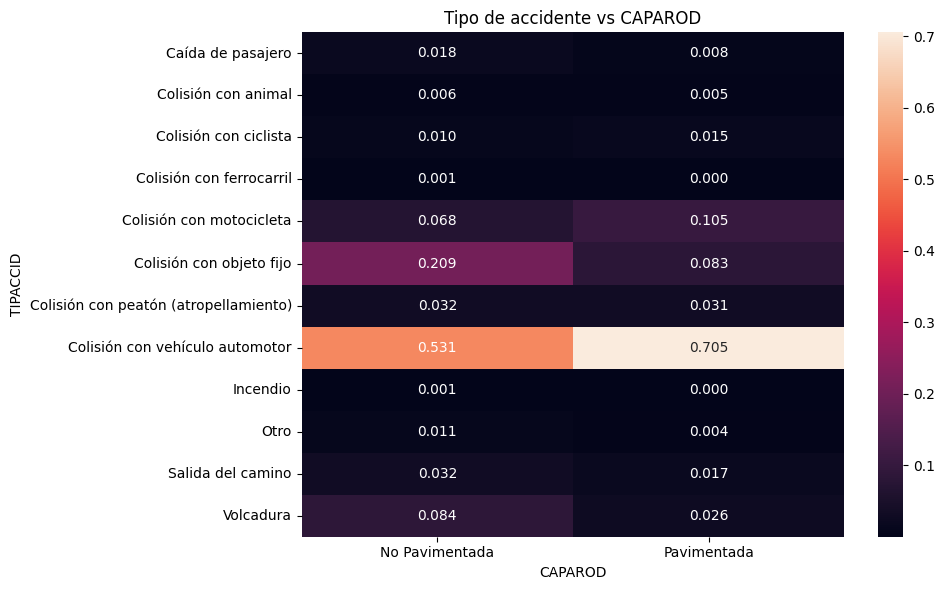

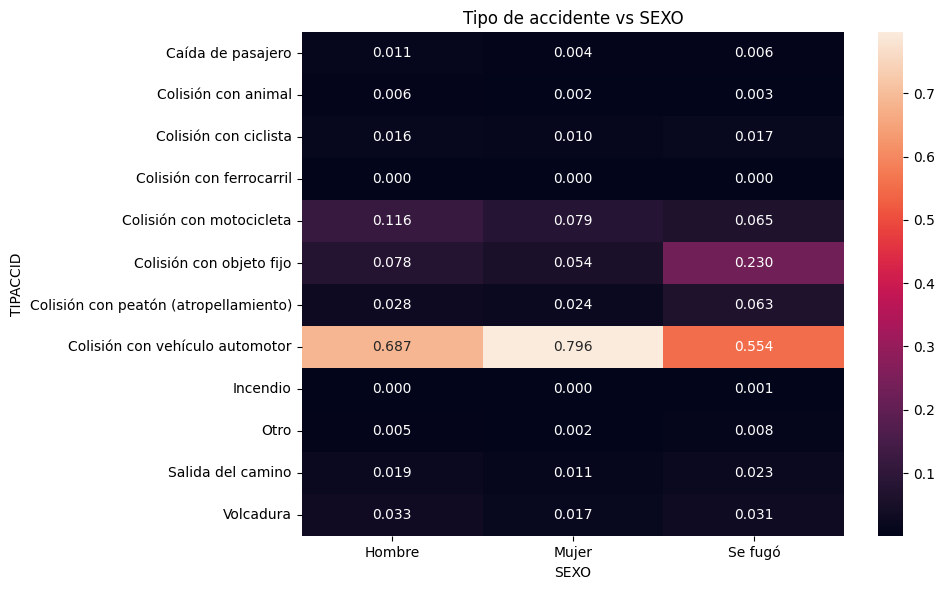

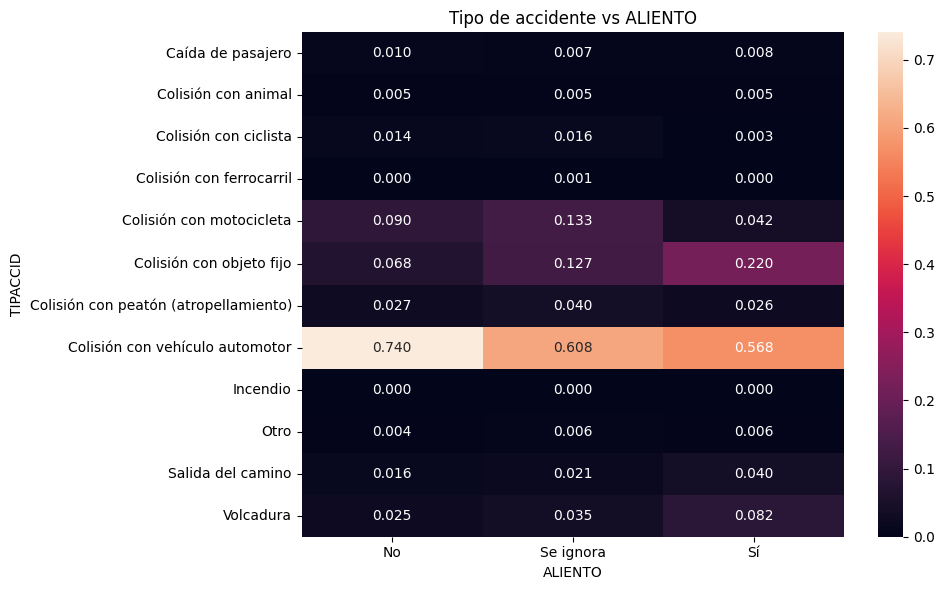

In [10]:
cat_cols2 = [
    'CAPAROD',
    'SEXO',
    'ALIENTO'
]
# Heatmaps
for col in cat_cols2:

    ct = pd.crosstab(
        inegi_df['TIPACCID'],
        inegi_df[col],
        dropna=True,
        normalize='columns'
    )

    plt.figure(figsize=(10, 6))
    sns.heatmap(ct, annot=True, fmt=".3f")
    plt.title(f"Tipo de accidente vs {col}")
    plt.tight_layout()
    plt.show()


In [11]:
inegi_df['CAPAROD'].value_counts()

CAPAROD
Pavimentada       133451
No Pavimentada      9190
Name: count, dtype: int64

In [12]:
inegi_df['SEXO'].value_counts()

SEXO
Hombre     95373
Mujer      30157
Se fugó    17111
Name: count, dtype: int64

In [13]:
inegi_df['ALIENTO'].value_counts() 

ALIENTO
No           93920
Se ignora    45173
Sí            3548
Name: count, dtype: int64

#### Observaciones del tipo de accidente:

- Causa de Accidente:
    - La mayoria de accidentes son por culpa del conductor, excepto:
        - **Incendios**, los cuales son por falla del vehiculo
        - **Colision con Animal**, los cuales son en parte por la mala condición del camino
        - **Atropellamiento**, los cuales son en parte por que un **pasajero o peaton** que distraen al conductor
- Dia de la Semana:
    - El martes tiene la menor cantidad de accidentes con **ferrocarriles** pero viernes y sabado tienen más que el resto de días
    - El domingo especificamente tiene una mayor cantidad de accidentes de tipo:
        - Colisión con objeto fijo
        - Salida del camino
        - Volcadura

Algunas variables no se lograban apreciar las diferencias, asi que las normalizamos con base a la columna en lugar del accidente:

- Calle Pavimentada:
    - La mayoria sucede en pavimentada pero esto es por la proporcion de accidentes en cada tipo
    - La colisión con objetos fijos sucede mayoritariamente en calles no pavimentadas
    - Las volcaduras son más comunes en calles no pavimentadas

- Sexo:
    - Los accidentes más comunes para los 2 sexos y los que se fugan es **Colisión con Vehiculo Automotor**
        - Las mujeres tienen una mayor proporción de este tipo de accidente comparado a los hombres y que se fugan
    - Cuando es **Colisión con Objeto Fijo** es más probable que se fuge el culpable
    - Los hombres tienen más colisiones con **Motocicleta**
    
- Aliento:
    - La gran mayoria de accidentes son causados por gente sin aliento alcoholico o se ignora por completo
    - Cuando es **Colisión con Objeto Fijo** es más probable que tengan aliento alcoholico

### Observando relaciones con causa de accidente
#### Utilizando Heatmaps


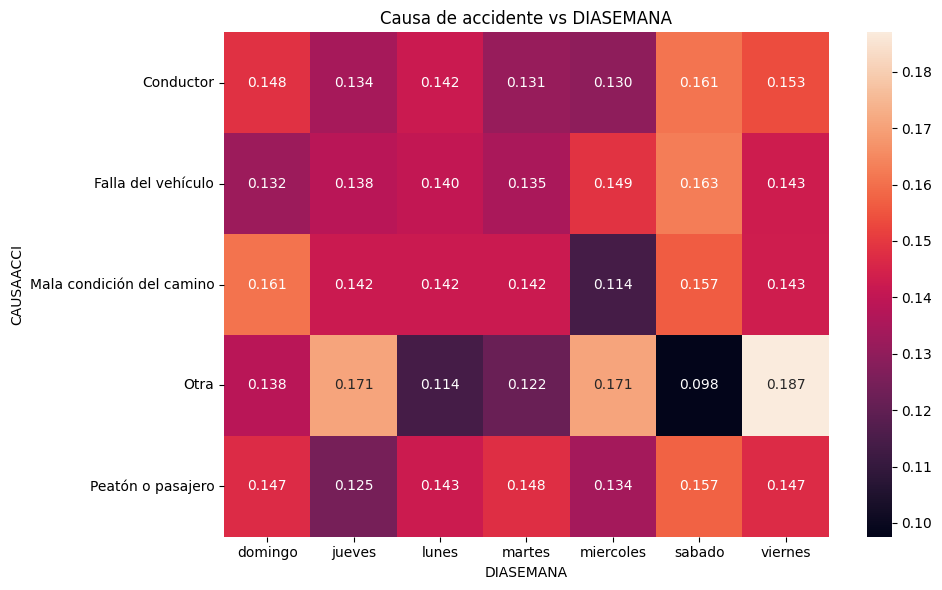

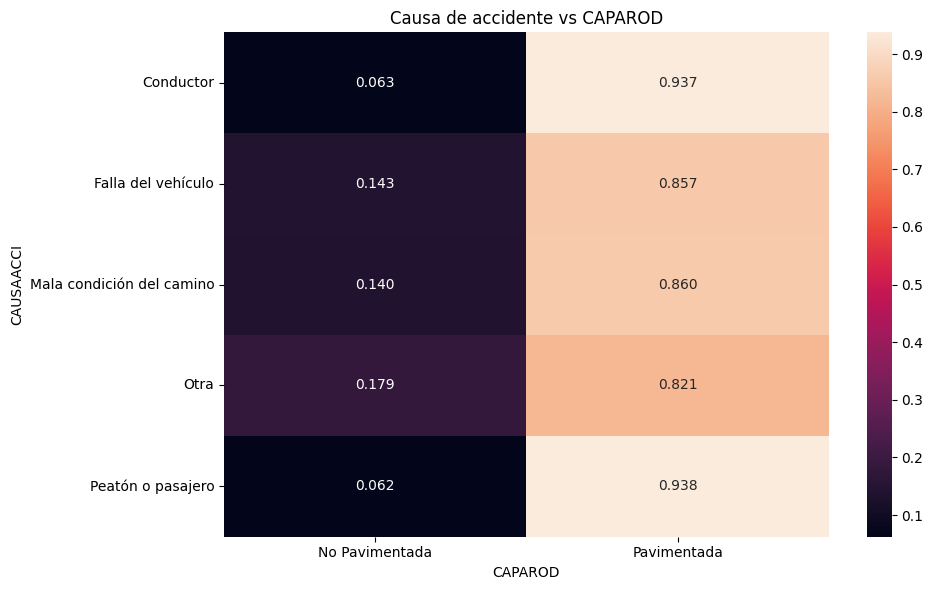

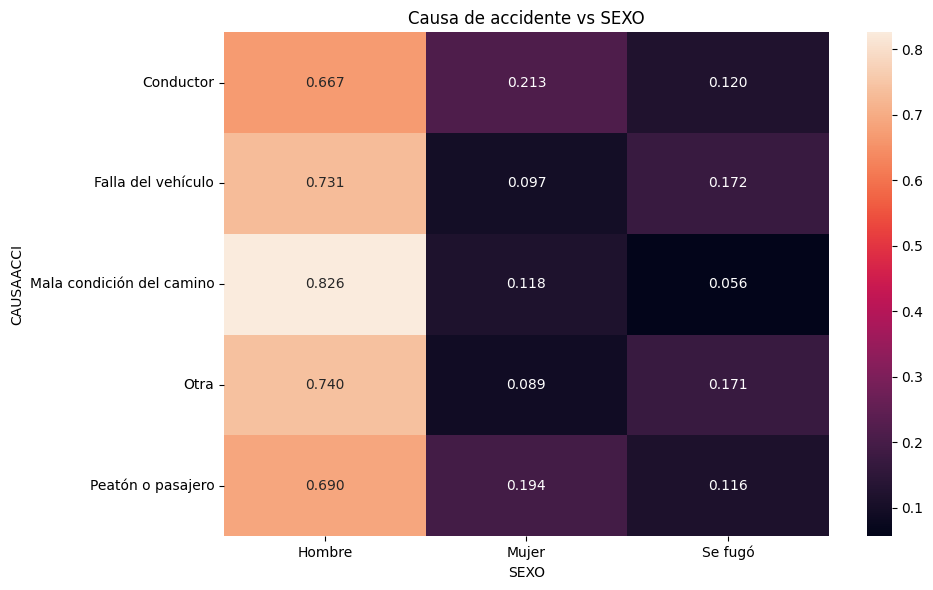

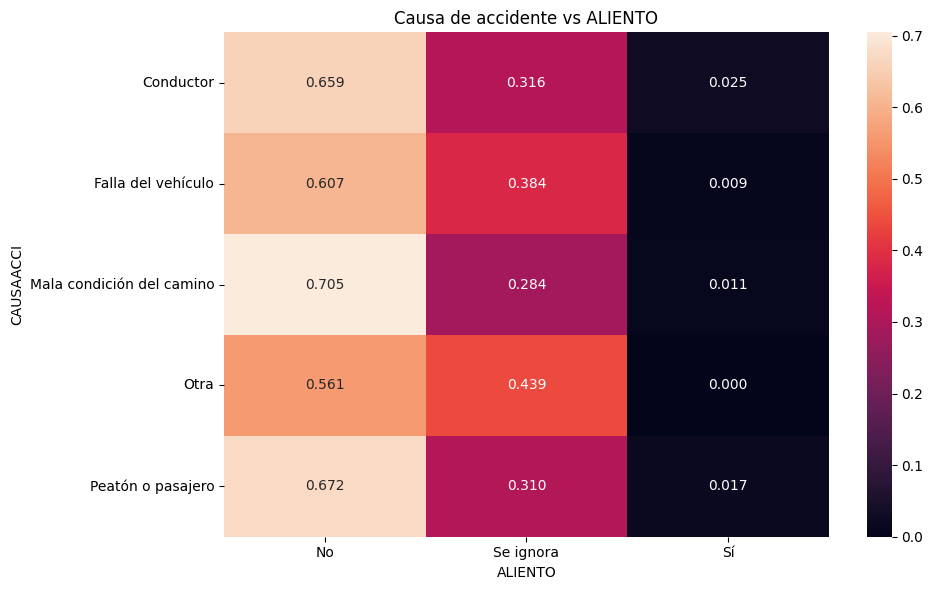

In [14]:
# Columnas categóricas importantes
cat_cols3 = [
    'DIASEMANA',
    'CAPAROD',
    'SEXO',
    'ALIENTO'
]

# Heatmaps
for col in cat_cols3:

    ct = pd.crosstab(
        inegi_df['CAUSAACCI'],
        inegi_df[col],
        dropna=True,
        normalize='index'
    )

    plt.figure(figsize=(10, 6))
    sns.heatmap(ct, annot=True, fmt=".3f")
    plt.title(f"Causa de accidente vs {col}")
    plt.tight_layout()
    plt.show()


In [15]:
inegi_df['CAUSAACCI'].value_counts()

CAUSAACCI
Conductor                    138601
Peatón o pasajero              1620
Falla del vehículo             1339
Mala condición del camino       958
Otra                            123
Name: count, dtype: int64

#### Observaciones de la causa de accidente:

- Dia de la Semana:
    - El viernes especificamente tiene una mayor causa de accidentes de tipo **Otra**
    - El sabado tiene menor mayor causa de accidentes tipo **Otra** pero más de **Falla de Vehiculo** y **Conductor** que otros días 

- Sexo:
    - La causa de accidentes más comunes para cada sexo es:
        - Mujeres: **Conductor**
        - Hombres: **Mala Condición del Camino**
        - Fugó: **Falla del Vehiculo** y **Otra**
    
- Aliento:
    - La mayor causa de accidentes de cada tipo de aliento son:
        - No: **Mala condicion del Camino**
        - Se ignora: **Otra**
        - Si: **Conductor**

Esta vez no cambiamos el tipo de normalización por que la mayoria son por culpa del conductor y esto no permite observar las demás variables.

### Comparacion de Causa y Tipo de Accidente con tipo de Vehiculo 

In [16]:
print((inegi_df['AUTOMOVIL'] > 0).sum())
print((inegi_df['AUTOMOVIL'] == 0).sum())

119971
22670


Como la mayoria de registros son de Automovil, los vamos a revisar por separado

#### Causa (Enfocado a Automovil)

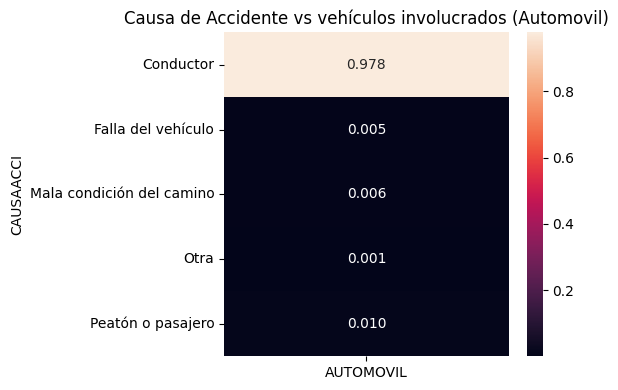

In [17]:
veh_cols = [
    'AUTOMOVIL'
]

# Crear columnas binarias de participación
veh_bin_df = inegi_df.copy()
for col in veh_cols:
    veh_bin_df[col] = (veh_bin_df[col] > 0).astype(int)

# Crosstab individual para cada tipo de vehículo
plt.figure(figsize=(6, 4))
heatmap_data = pd.DataFrame()

for col in veh_cols:
    ct_temp = pd.crosstab(
        veh_bin_df['CAUSAACCI'],
        veh_bin_df[col],
        normalize='columns'
    )[1]  # Solo tomamos la columna que representa la presencia del vehículo
    heatmap_data[col] = ct_temp

sns.heatmap(heatmap_data, annot=True, fmt=".3f")
plt.title("Causa de Accidente vs vehículos involucrados (Automovil)")
plt.tight_layout()
plt.show()

Observaciones:
Podemos ver que la mayor causa de accidentes es por culpa del conductor por  una gran mayoria

#### Tipo (Enfocado a Automovil)

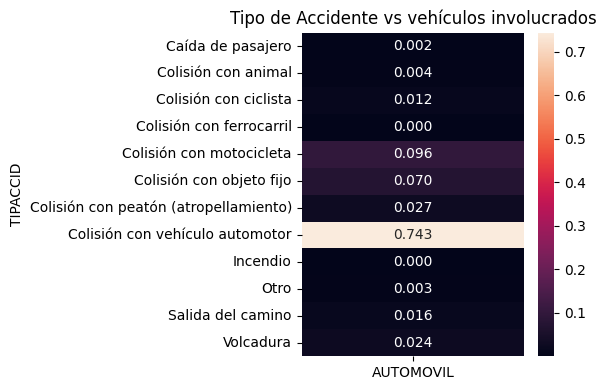

In [18]:
# Crear columnas binarias de participación
veh_bin_df = inegi_df.copy()
for col in veh_cols:
    veh_bin_df[col] = (veh_bin_df[col] > 0).astype(int)

# Crosstab individual para cada tipo de vehículo
plt.figure(figsize=(6, 4))
heatmap_data = pd.DataFrame()

for col in veh_cols:
    ct_temp = pd.crosstab(
        veh_bin_df['TIPACCID'],
        veh_bin_df[col],
        normalize='columns'
    )[1]  # Solo tomamos la columna que representa la presencia del vehículo
    heatmap_data[col] = ct_temp

sns.heatmap(heatmap_data, annot=True, fmt=".3f")
plt.title("Tipo de Accidente vs vehículos involucrados")
plt.tight_layout()
plt.show()


Observaciones:

El mayor tipo de accidente es por **Colision con vehiculo automotor**, seguido por **Colisión con motocicleta** aunque la diferencia es muy grande.

#### Omitiendo Automovil

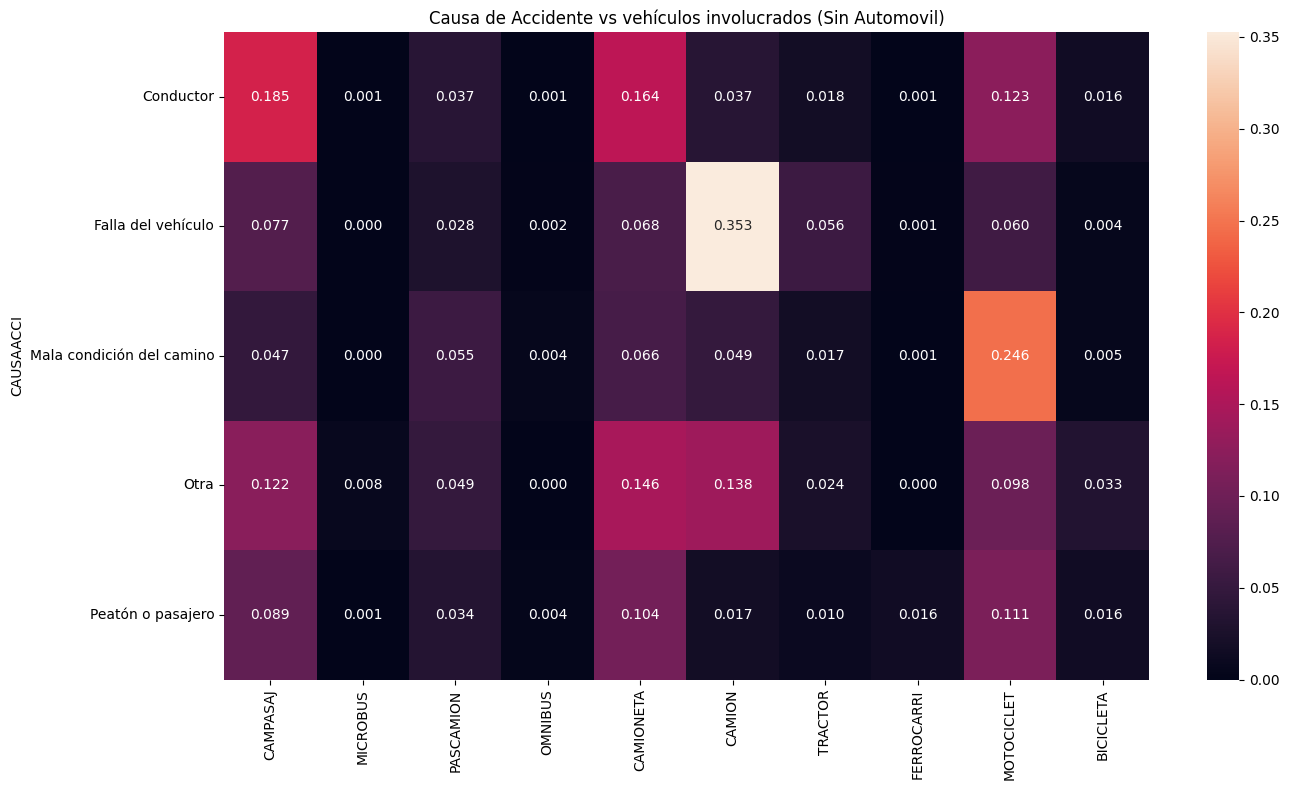

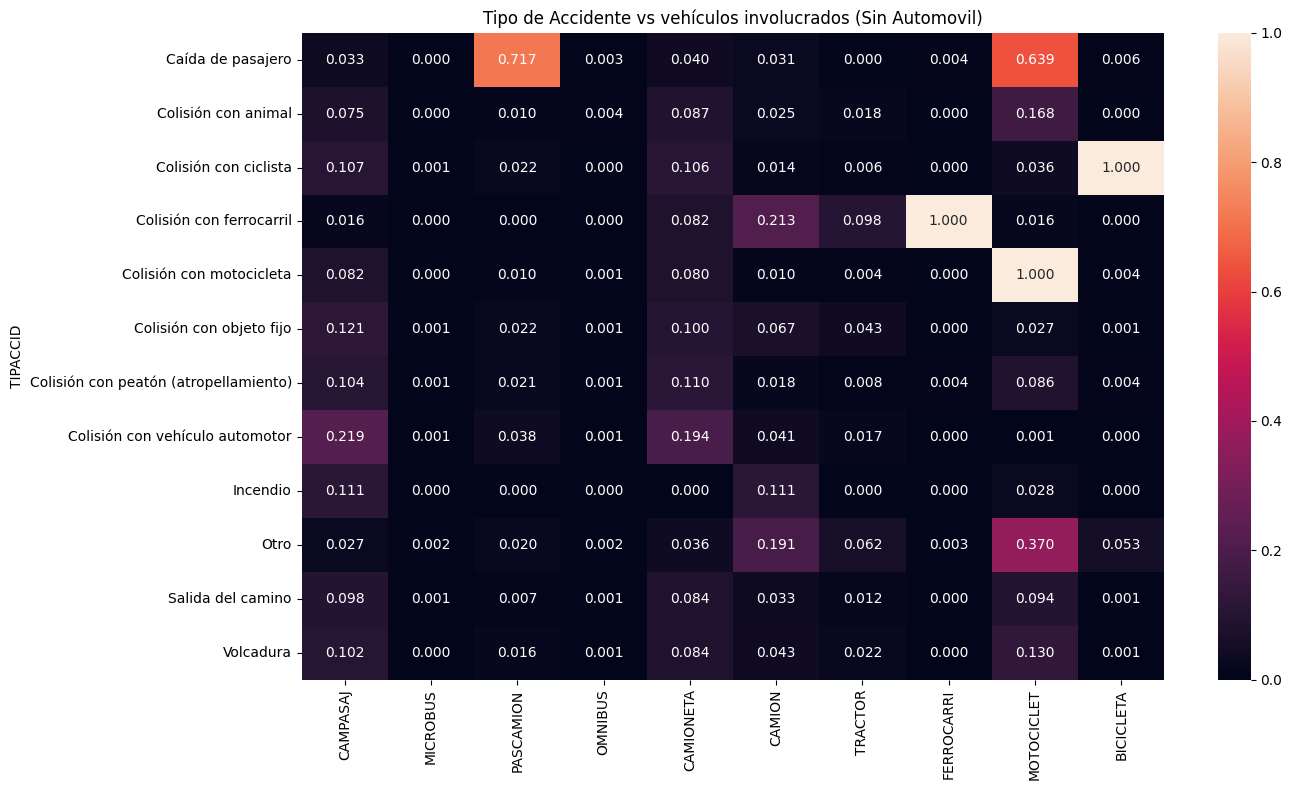

In [19]:
veh_cols = [
    'CAMPASAJ','MICROBUS','PASCAMION','OMNIBUS',
    'CAMIONETA','CAMION','TRACTOR','FERROCARRI','MOTOCICLET','BICICLETA'
]

# Crear columnas binarias de participación
veh_bin_df = inegi_df.copy()
for col in veh_cols:
    veh_bin_df[col] = (veh_bin_df[col] > 0).astype(int)

# Crosstab individual para cada tipo de vehículo
plt.figure(figsize=(14, 8))
heatmap_data = pd.DataFrame()

for col in veh_cols:
    ct_temp = pd.crosstab(
        veh_bin_df['CAUSAACCI'],
        veh_bin_df[col],
        normalize='index'
    )[1]  # Solo tomamos la columna que representa la presencia del vehículo
    heatmap_data[col] = ct_temp

sns.heatmap(heatmap_data, annot=True, fmt=".3f")
plt.title("Causa de Accidente vs vehículos involucrados (Sin Automovil)")
plt.tight_layout()
plt.show()

# Crear columnas binarias de participación
veh_bin_df = inegi_df.copy()
for col in veh_cols:
    veh_bin_df[col] = (veh_bin_df[col] > 0).astype(int)

# Crosstab individual para cada tipo de vehículo
plt.figure(figsize=(14, 8))
heatmap_data = pd.DataFrame()

for col in veh_cols:
    ct_temp = pd.crosstab(
        veh_bin_df['TIPACCID'],
        veh_bin_df[col],
        normalize='index'
    )[1]  # Solo tomamos la columna que representa la presencia del vehículo
    heatmap_data[col] = ct_temp

sns.heatmap(heatmap_data, annot=True, fmt=".3f")
plt.title("Tipo de Accidente vs vehículos involucrados (Sin Automovil)")
plt.tight_layout()
plt.show()


#### Observaciones:
- Causa de Accidentes:
    - Los vehiculos que tienen más accidentes causados por el conductor son:
        - Camion de Pasajeros
        - Camioneta
        - Motocicleta
    - En falla de vehiculo, la mayoria son por:
        - Camion (De carga)
    - Por mala condicion del camino es:
        - Motocicleta
    - Por otro:
        - Camion de Pasajeros
        - Camioneta
        - Motocicleta
        - Camion (De carga)
    - Por culpa del pasajero o peaton:
        - Camion de Pasajeros
        - Camioneta
        - Motocicleta
    - Los vehiculos con la menor cantidad de accidentes son el Mircobus, Omnibus, Ferrocarril y Bicicleta

- Tipo de Accidente:
    - En caida de Pasajero, la mayoria estan dadas por:
        - Camion de Pasajeros
        - Motocicleta
    - En otro solo resalta el vehiculo:
        - Motocicleta
        
    - Hay algunos vehiculos que tienen 1.0 en su valor pero es por que el tipo de accidente involucra el vehiculo en especifico.

## Utilizando reducción de caracteristicas para crear otras visualizaciones

Primero hay que revisar cuantas variables son suficientes para explicar la mayoria del problema

Columnas numéricas consideradas: 20
Columnas constantes eliminadas: []

Componentes necesarios por umbral de varianza explicada:
  80% -> 14 componentes
  90% -> 16 componentes
  95% -> 17 componentes
  99% -> 18 componentes


,component,explained_variance_ratio,cumulative_explained
0,1,1.026927e-01,0.102693
1,2,8.275959e-02,0.185452
2,3,6.271211e-02,0.248164
3,4,5.499977e-02,0.303164
4,5,5.319025e-02,0.356354
5,6,5.165894e-02,0.408013
6,7,5.134145e-02,0.459355
7,8,5.082626e-02,0.510181
8,9,5.061967e-02,0.560801
9,10,5.037791e-02,0.611179


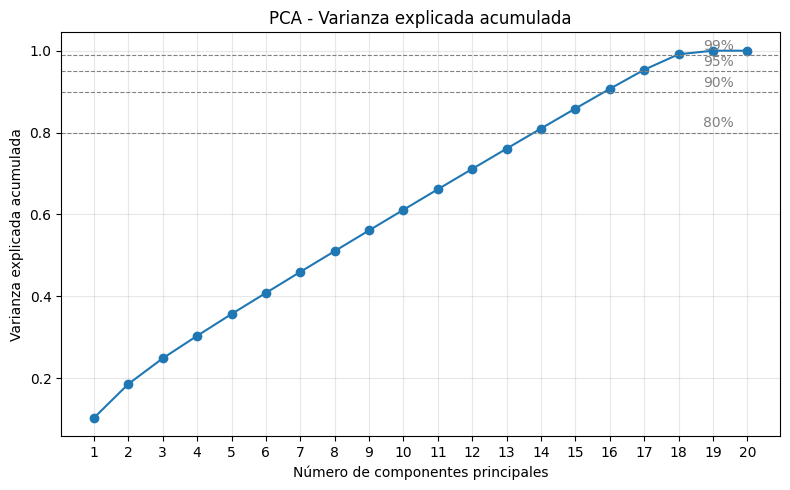

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# PCA para determinar cuántas variables conservar (explicabilidad)

# Seleccionar columnas numéricas y eliminar constantes
num_cols = inegi_df.select_dtypes(include=[np.number]).columns.tolist()
X_num = inegi_df[num_cols].copy()
const_cols = X_num.columns[X_num.nunique() <= 1].tolist()
if const_cols:
    X_num = X_num.drop(columns=const_cols)

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# Ajustar PCA completo
pca = PCA()
pca.fit(X_scaled)
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

# Umbrales comunes y número de componentes necesarios
thresholds = [0.80, 0.90, 0.95, 0.99]
needed = {t: int(np.searchsorted(cum_explained, t) + 1) for t in thresholds}

# Mostrar resultados resumidos
print("Columnas numéricas consideradas:", len(X_num.columns))
print("Columnas constantes eliminadas:", const_cols)
print("\nComponentes necesarios por umbral de varianza explicada:")
for t, n in needed.items():
    print(f"  {int(t*100)}% -> {n} componentes")

# Tabla con varianza explicada acumulada por componente
var_df = pd.DataFrame({
    'component': np.arange(1, len(explained)+1),
    'explained_variance_ratio': explained,
    'cumulative_explained': cum_explained
})
display(var_df.head(20))  # mostrar primeras 20 filas

# Gráfica Scree / Varianza acumulada
plt.figure(figsize=(8,5))
plt.plot(var_df['component'], var_df['cumulative_explained'], marker='o')
for t in thresholds:
    plt.axhline(y=t, color='gray', linestyle='--', linewidth=0.8)
    plt.text(len(explained)*0.98, t+0.005, f"{int(t*100)}%", ha='right', va='bottom', color='gray')
plt.xticks(np.arange(1, len(explained)+1, max(1, len(explained)//20)))
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA - Varianza explicada acumulada')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Parece que la mejor cantidad de componentes se encuentra entre 16 y 17 para mantener la explicabilidad de 90% - 95%.

In [21]:
# Ajustar PCA solo con los componentes que quieres conservar
pca17 = PCA(n_components=17)
X_pca17 = pca17.fit_transform(X_scaled)

# Convertir a DataFrame
pca_cols = [f"PC{i+1}" for i in range(17)]
pca_df = pd.DataFrame(X_pca17, columns=pca_cols, index=inegi_df.index)

# Unir con variables categóricas si quieres analizarlas juntas
combined_df = pd.concat([pca_df, inegi_df], axis=1)


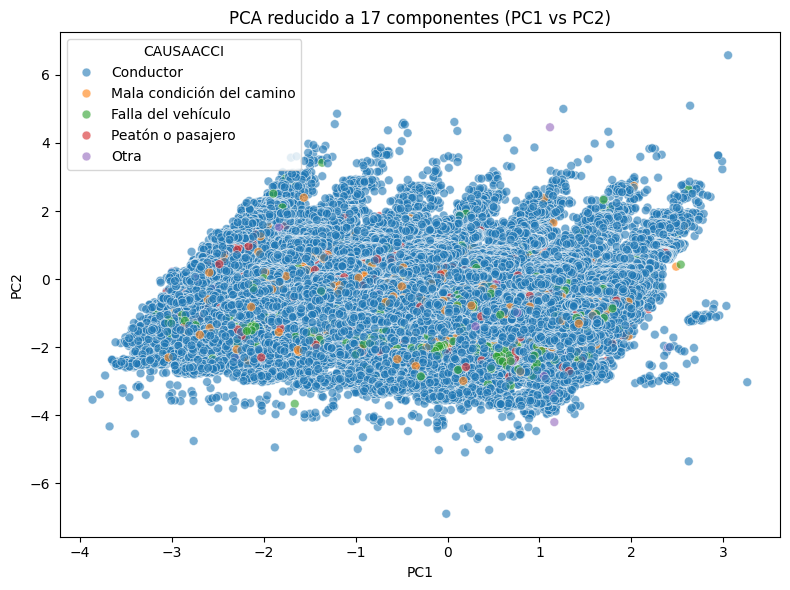

In [22]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='PC1',
    y='PC2',
    data=pca_df.join(inegi_df['CAUSAACCI']),
    hue='CAUSAACCI',
    alpha=0.6,
    s=40
)
plt.title('PCA reducido a 17 componentes (PC1 vs PC2)')
plt.tight_layout()
plt.show()


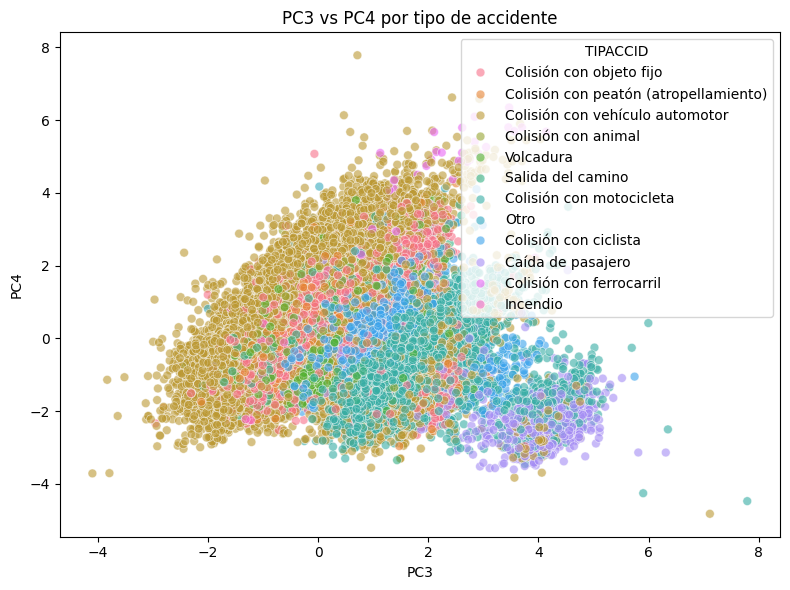

In [23]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='PC3',
    y='PC4',
    data=pca_df.join(inegi_df['TIPACCID']),
    hue='TIPACCID',
    alpha=0.6,
    s=40
)
plt.title('PC3 vs PC4 por tipo de accidente')
plt.tight_layout()
plt.show()


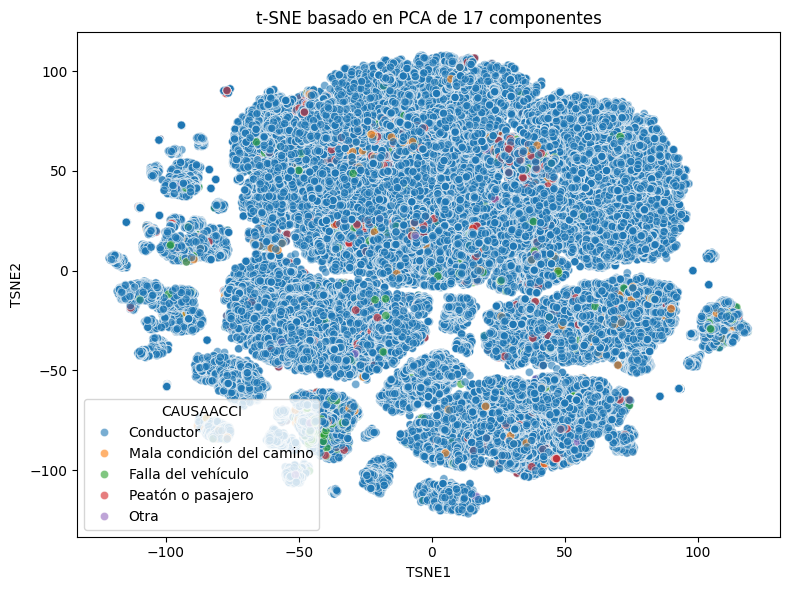

In [24]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=40, learning_rate='auto')
X_tsne = tsne.fit_transform(X_pca17)

tsne_df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'], index=inegi_df.index)

# Graficar
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='TSNE1',
    y='TSNE2',
    data=tsne_df.join(inegi_df['CAUSAACCI']),
    hue='CAUSAACCI',
    alpha=0.6,
    s=35
)
plt.title('t-SNE basado en PCA de 17 componentes')
plt.tight_layout()
plt.show()


Sin volver a entrenar, voy a graficar los resultados sin la variable 'Conductor'

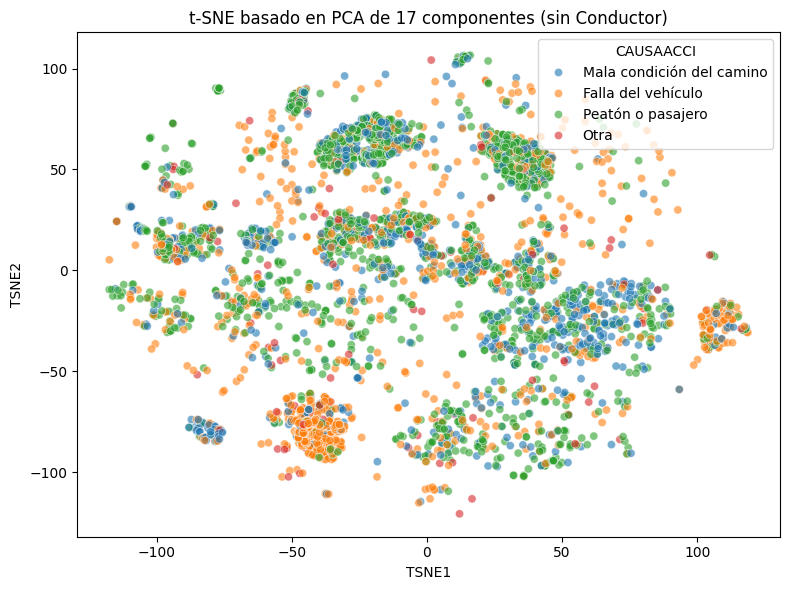

In [25]:
tsne_df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'], index=inegi_df.index)

# Unir TSNE + columna de causa
plot_df = tsne_df.join(inegi_df['CAUSAACCI'])

# Filtrar para excluir "Conductor"
plot_df = plot_df[plot_df['CAUSAACCI'] != "Conductor"]

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='TSNE1',
    y='TSNE2',
    data=plot_df,
    hue='CAUSAACCI',
    alpha=0.6,
    s=35
)
plt.title('t-SNE basado en PCA de 17 componentes (sin Conductor)')
plt.tight_layout()
plt.show()


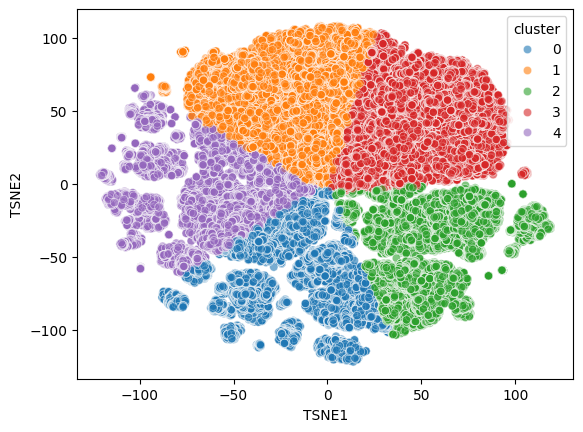

In [26]:
from sklearn.cluster import KMeans

k = 5   # ajusta según lo veas en la gráfica
kmeans = KMeans(n_clusters=k, random_state=32)
clusters = kmeans.fit_predict(X_tsne)

tsne_df['cluster'] = clusters

sns.scatterplot(
    x='TSNE1', y='TSNE2',
    data=tsne_df,
    hue='cluster',
    palette='tab10',
    alpha=0.6
)
plt.show()


d:\MasterHDXD\Escuela\Maestria\Ingenieria_de_caracteristicas\Proyecto\proyecto_ing_datos\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\MasterHDXD\Escuela\Maestria\Ingenieria_de_caracteristicas\Proyecto\proyecto_ing_datos\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
d:\MasterHDXD\Escuela\Maestria\Ingenieria_de_caracteristicas\Proyecto\proyecto_ing_datos\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


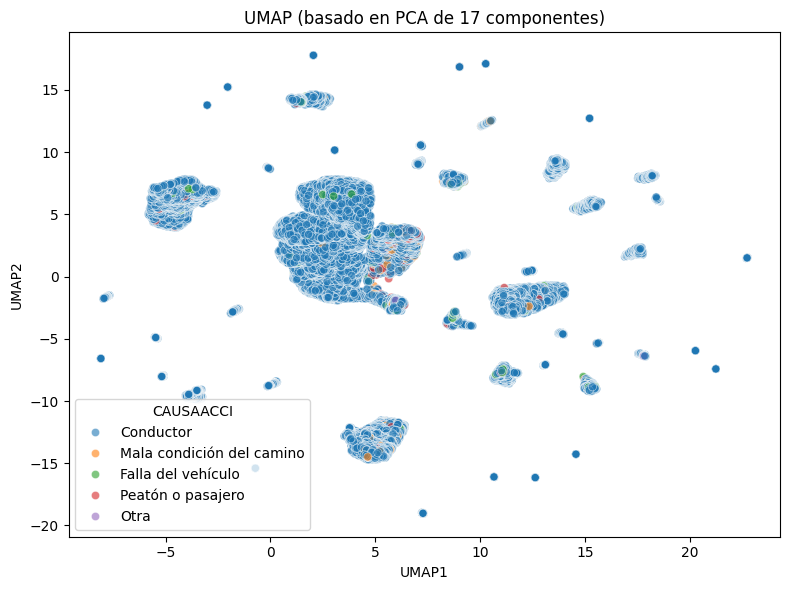

In [ ]:
import umap

# Suponiendo que ya tienes tus datos escalados en X_pca17
# y que inegi_df tiene la columna CAUSAACCI

umap_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    metric='euclidean',
    random_state=42
)

X_umap = umap_model.fit_transform(X_pca17)

umap_df = pd.DataFrame(
    X_umap,
    columns=['UMAP1', 'UMAP2'],
    index=inegi_df.index
)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=umap_df.join(inegi_df['CAUSAACCI']),
    x='UMAP1',
    y='UMAP2',
    hue='CAUSAACCI',
    alpha=0.6,
    s=35
)
plt.title("UMAP (basado en PCA de 17 componentes)")
plt.tight_layout()
plt.show()
